# Flux Footprint Climatology Tutorial
This Jupyter notebook demonstrates how to use the custom `FFPclim` class (defined in `new_ffp.py`) to compute a flux footprint climatology from tower‐based micrometeorological data.

You will learn how to:
1. Load and inspect the half‐hourly data provided in the CSV file.
2. Instantiate the `FFPclim` model with sensible parameters.
3. Run the model to generate a 2‑D footprint climatology.
4. Visualise and save the results for further analysis.

The workflow should run on a standard scientific Python stack with `pandas`, `numpy`, `scipy`, `xarray`, and `matplotlib` installed.

## 1. Environment setup
Make sure you have the necessary libraries. If something is missing, install it (for example with `pip`).

In [ ]:
!pip install -q pandas numpy scipy xarray matplotlib

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path

import os
import sys

# Add current directory to sys.path so Python can find improved_ffp.py
sys.path.insert(0, os.path.abspath("../../src"))  # adjust path as needed
from fluxfootprints import FFPclim

plt.rcParams['figure.figsize'] = (6, 5)

In [9]:
import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
console_handler = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

## 3. Load the half‑hourly data

In [3]:
DATA_PATH = Path('US-UTE_HH_202406241430_202409251400.csv')
df_raw = pd.read_csv(DATA_PATH, parse_dates=['datetime_start'], index_col='datetime_start')
print(f"Loaded {len(df_raw):,} records")
df_raw.head()

Loaded 4,463 records


,TIMESTAMP_START,TIMESTAMP_END,CO2,CO2_SIGMA,H2O,H2O_SIGMA,FC,FC_SSITC_TEST,LE,LE_SSITC_TEST,...,TA_1_2_1,RH_1_2_1,T_DP_1_2_1,TA_1_3_1,RH_1_3_1,T_DP_1_3_1,TA_1_4_1,PBLH_F,TS_2_1_1,SWC_2_1_1
datetime_start,,,,,,,,,,,,,,,,,,,,,
2024-06-24 14:30:00,202406241430,202406241500,427.0199,0.628133,17.26862,1.019290,0.069210,-9999.0,156.40850,-9999.0,...,29.95141,33.26877,12.052600,30.32464,33.45364,12.46181,30.06976,1665.4670,25.72815,22.44161
2024-06-24 15:00:00,202406241500,202406241530,425.9499,1.019297,15.18936,0.703052,0.285446,-9999.0,138.30920,-9999.0,...,30.02516,29.22197,10.155240,30.35956,29.77183,10.72635,30.13765,1765.9350,25.52736,22.41975
2024-06-24 15:30:00,202406241530,202406241600,426.4163,1.965228,14.87533,0.808026,1.081928,-9999.0,154.11530,-9999.0,...,30.24634,28.28498,9.838229,30.69433,28.63222,10.41335,30.40344,1495.7350,25.12511,22.32785
2024-06-24 16:00:00,202406241600,202406241630,426.0534,2.665907,15.61140,1.002919,0.519664,-9999.0,135.56180,-9999.0,...,30.75179,28.75255,10.538220,31.14621,29.16225,11.09066,30.90061,1491.0620,24.63557,22.18172
2024-06-24 16:30:00,202406241630,202406241700,427.8476,1.102921,15.21034,0.703084,1.147608,-9999.0,95.06287,-9999.0,...,29.16274,30.77158,10.165810,29.57434,30.96792,10.63069,29.30510,341.9711,24.14865,22.03216


### 3.1 Clean and inspect key columns
The `FFPclim` class expects certain column names. Below we rename the most common AmeriFlux/ICOS style names if necessary.

In [14]:
# Example mapping – adjust if your column names differ
col_map = {
    'WD': 'wind_dir',          # wind direction (deg)
    'USTAR': 'USTAR',          # friction velocity (m s‑1)
    'WS': 'ws',                # mean wind speed (m s‑1)
    'SIGMA_V': 'V_SIGMA',      # std dev of lateral wind (m s‑1)
    'MO_LENGTH': 'MO_LENGTH',  # Obukhov length (m)
}
df = df_raw.rename(columns={k:v for k,v in col_map.items() if k in df_raw.columns})

# Drop rows with obviously bad or missing data in key columns
key_cols = ['wind_dir', 'USTAR', 'ws', 'V_SIGMA', 'MO_LENGTH']
df = df.dropna(subset=key_cols)
df = df.iloc[:100,:]  # Limit to first 100 rows for demo purposes

## 4. Instantiate `FFPclim`

In [18]:
ffp = FFPclim(
    df=df,
    domain=[-100, 100, -100, 100],  # metres from tower
    dx=10, dy=10,
    smooth_data=True,
    verbosity=1,
    logger=logger,
)
ffp

## 5. Run the footprint calculation

In [19]:
results = ffp.run()
results.keys()

c:\Users\paulinkenbrandt\.conda\envs\py313\Lib\site-packages\xarray\core\computation.py:824: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


dict_keys(['x_2d', 'y_2d', 'fclim_2d', 'f_2d', 'rs'])

## 6. Visualise the footprint climatology

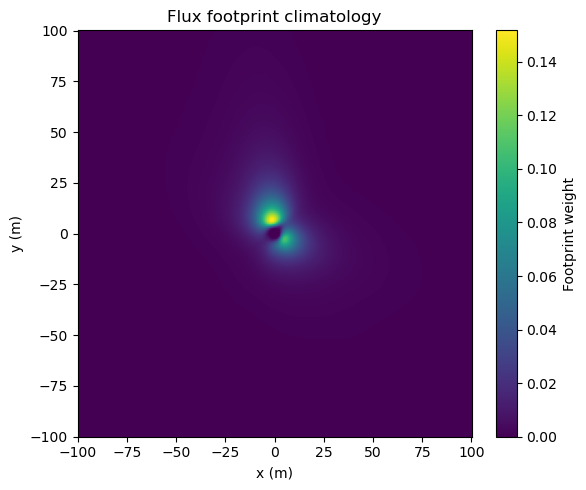

In [20]:
fclim = results['fclim_2d']

plt.figure()
pc = plt.pcolormesh(ffp.x, ffp.y, fclim.T, shading='auto', cmap='viridis')
plt.colorbar(pc, label='Footprint weight')
plt.contour(ffp.x, ffp.y, fclim.T / fclim.sum(), levels=[0.1,0.2,0.3,0.5,0.8], colors='w')
plt.title('Flux footprint climatology')
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.tight_layout()

## 7. Save results

In [ ]:
nc_path = Path('footprint_climatology.nc')
fclim.to_netcdf(nc_path)
print(f'Saved NetCDF to {nc_path.resolve()}')

## 8. Next steps
- Compare different months or stability classes.
- Overlay the footprint with land‑cover maps or lidar canopy height models.
- Couple the footprint to flux partitioning or inverse modelling workflows.